Visualizing: BA2_96_1_A6_nosplit
Timepoints: 11 days
Days: [3.0, 6.0, 8.0, 10.0, 13.0, 15.0, 17.0, 20.5, 24.0, 28.0, 30.0]
Loaded 11 masks


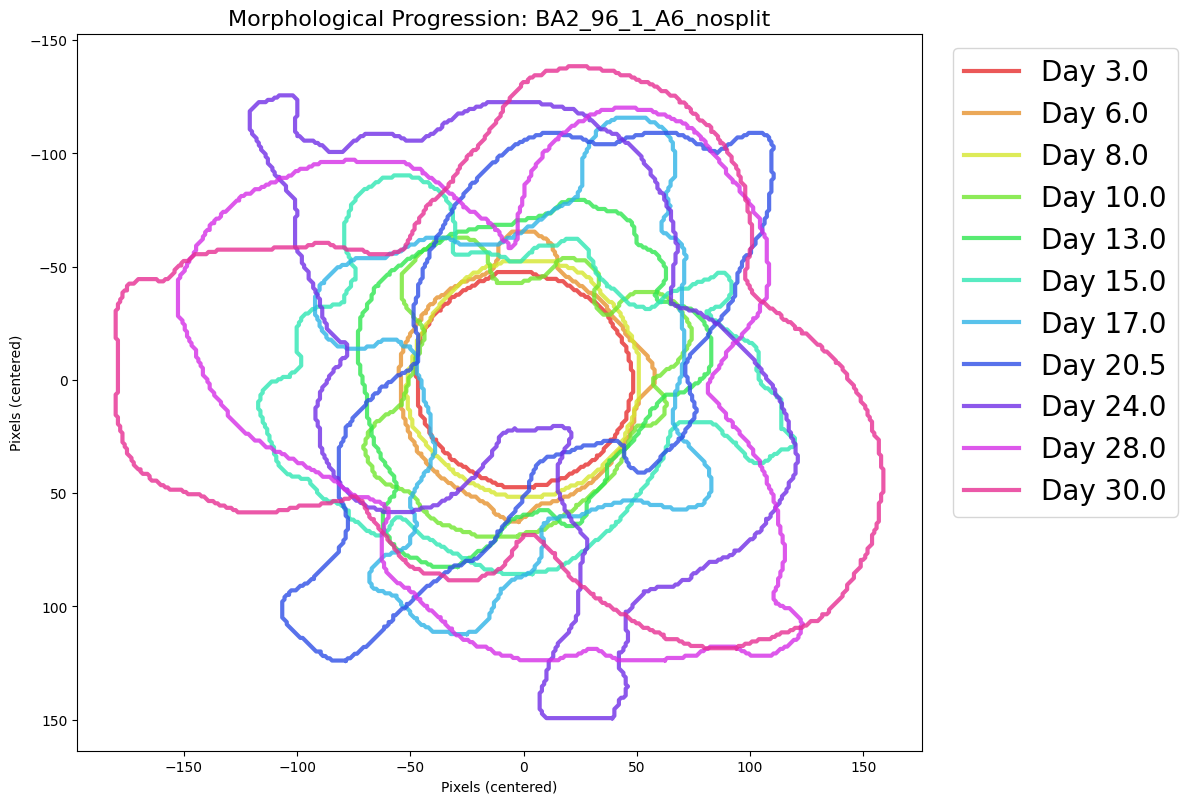

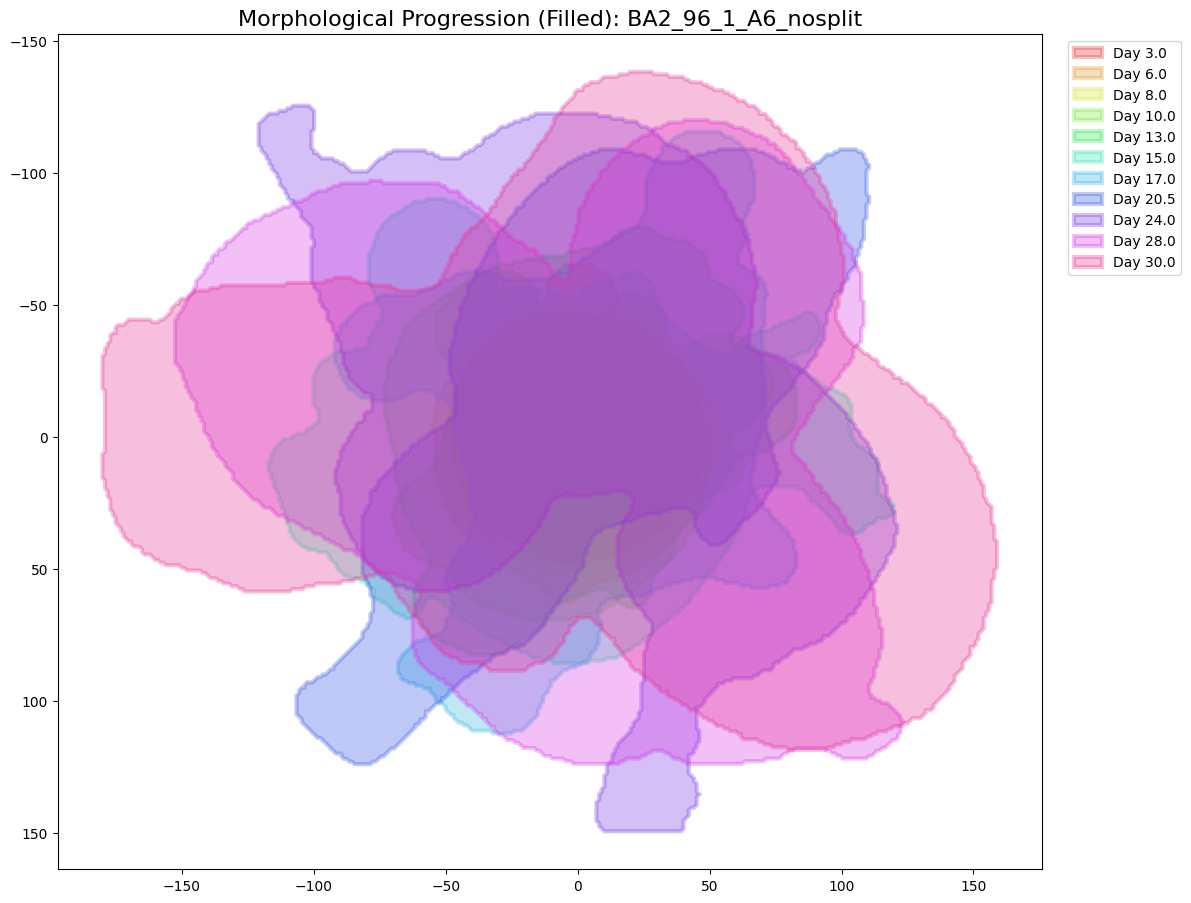

In [16]:
# notebooks/visualize_organoid_morphology_progression.ipynb

import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from skimage.io import imread
from skimage.measure import find_contours
from pathlib import Path
import sys, os, json


# --- Add repo root so `from config import ALL_DATA_JSON` works ---
def add_repo_root(markers=("config.py", ".env")):
    here = Path.cwd()
    for p in [here, *here.parents]:
        if all((p / m).exists() for m in markers):
            sys.path.insert(0, str(p))
            return p
    raise RuntimeError("Could not find repo root with config.py and .env")

repo_root = add_repo_root()

from config import ALL_DATA_JSON, OUTPUT_FOLDER  # now this should import


def load_json(p):
    with open(p) as f:
        return json.load(f)

# Load series metadata
series_metadata = load_json(OUTPUT_FOLDER / 'complete_series_metadata_no_blanks.json')
data = load_json(OUTPUT_FOLDER / 'complete_series_data_no_blanks.json')

# Pick an organoid to visualize
organoid_id = list(series_metadata.keys())[100]  # First one
print(f"Visualizing: {organoid_id}")

series = series_metadata[organoid_id]
print(f"Timepoints: {len(series['days'])} days")
print(f"Days: {series['days']}")

# Load all masks for this series
masks = []
days = []
for entry_key in series['entry_keys']:
    entry = data[entry_key]
    if 'lstm_processed' in entry and entry['lstm_processed']['mask_path']:
        mask_path = entry['lstm_processed']['mask_path']
        mask = imread(mask_path)
        masks.append(mask)
        days.append(entry['mdl_day'])
        
print(f"Loaded {len(masks)} masks")

# Function to get contour and centroid
def get_contour_and_centroid(mask):
    """Extract outer contour and calculate centroid"""
    # Find contours (level=0.5 for binary mask)
    contours = find_contours(mask, level=0.5)
    
    if not contours:
        return None, None
    
    # Get largest contour (outer boundary)
    contour = max(contours, key=len)
    
    # Calculate centroid
    centroid = contour.mean(axis=0)
    
    return contour, centroid

# Extract and center all contours
centered_contours = []
for mask in masks:
    contour, centroid = get_contour_and_centroid(mask)
    if contour is not None:
        # Center the contour by subtracting centroid
        centered = contour - centroid
        centered_contours.append(centered)
    else:
        centered_contours.append(None)

# Create rainbow colors (HSV -> RGB)
n_timepoints = len(centered_contours)
colors = []
for i in range(n_timepoints):
    hue = i / n_timepoints  # 0 to 1 (red -> violet)
    rgb = hsv_to_rgb([hue, 0.8, 0.9])  # Saturated, bright colors
    colors.append(rgb)

# Plot all contours overlaid
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

for i, (contour, day) in enumerate(zip(centered_contours, days)):
    if contour is not None:
        # Plot contour (swap x,y for correct orientation)
        ax.plot(contour[:, 1], contour[:, 0], 
               color=colors[i], linewidth=3, 
               label=f'Day {day:.1f}', alpha=0.8)

ax.set_aspect('equal')
ax.invert_yaxis()  # Match image coordinates
ax.set_title(f'Morphological Progression: {organoid_id}', fontsize=16)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=20)
ax.grid(False)
ax.set_xlabel('Pixels (centered)')
ax.set_ylabel('Pixels (centered)')

plt.tight_layout()
plt.show()

# Also create a version with filled contours for "heat map" effect
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

for i, (contour, day) in enumerate(zip(centered_contours, days)):
    if contour is not None:
        ax.fill(contour[:, 1], contour[:, 0], 
               color=colors[i], alpha=0.3, edgecolor=colors[i], 
               linewidth=3, label=f'Day {day:.1f}')

ax.set_aspect('equal')
ax.invert_yaxis()
ax.set_title(f'Morphological Progression (Filled): {organoid_id}', fontsize=16)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
ax.grid(False)

plt.tight_layout()
plt.show()

In [19]:
import json
from collections import Counter
from config import OUTPUT_FOLDER

# Load data
data = json.load(open(OUTPUT_FOLDER / 'complete_series_data_no_blanks.json'))
series_metadata = json.load(open(OUTPUT_FOLDER / 'complete_series_metadata_no_blanks.json'))

def get_label_from_survey(entry):
    """
    Extract binary label from survey data using majority vote
    Returns: 1 (Acceptable/Good), 0 (Not Acceptable/Bad), or None (no data)
    """
    if 'survey' not in entry or not entry['survey']:
        return None
    
    survey = entry['survey']
    
    if 'evaluations' not in survey or not survey['evaluations']:
        return None
    
    # Count votes from all evaluators
    votes = [ev.get('evaluation') for ev in survey['evaluations']]
    
    acceptable_count = votes.count('Acceptable')
    not_acceptable_count = votes.count('Not Acceptable')
    
    # Majority vote
    if acceptable_count > not_acceptable_count:
        return 1  # Good
    elif not_acceptable_count > acceptable_count:
        return 0  # Bad
    else:
        # Tie - skip this organoid
        return None

# Check labels for complete series
organoid_labels = {}

for organoid_id in series_metadata.keys():
    # Get the final timepoint (Day 30) for this organoid
    entry_keys = series_metadata[organoid_id]['entry_keys']
    final_entry = data[entry_keys[-1]]  # Last day
    
    label = get_label_from_survey(final_entry)
    if label is not None:
        organoid_labels[organoid_id] = label

# Analysis
print(f"Total complete series: {len(series_metadata)}")
print(f"Series with labels: {len(organoid_labels)}")
print(f"Percentage with labels: {100*len(organoid_labels)/len(series_metadata):.1f}%\n")

label_counts = Counter(organoid_labels.values())
print(f"Class distribution:")
print(f"  Good (Acceptable): {label_counts[1]}")
print(f"  Bad (Not Acceptable): {label_counts[0]}")
print(f"  Balance: {100*label_counts[1]/(label_counts[0]+label_counts[1]):.1f}% good\n")

# Show some examples
print("Examples:")
for i, (org_id, label) in enumerate(list(organoid_labels.items())[:5]):
    print(f"  {org_id}: {'Good' if label == 1 else 'Bad'}")

Total complete series: 410
Series with labels: 316
Percentage with labels: 77.1%

Class distribution:
  Good (Acceptable): 199
  Bad (Not Acceptable): 117
  Balance: 63.0% good

Examples:
  BA1_96_1_A11_nosplit: Good
  BA1_96_1_A2_nosplit: Good
  BA1_96_1_A3_nosplit: Good
  BA1_96_1_A5_nosplit: Good
  BA1_96_1_A7_nosplit: Good
